<a href="https://colab.research.google.com/github/znr6s28ynr-maker/Machine-Learning/blob/main/CS_6600_Assignment_3_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS-6600 Assignment 3 - Classification

**Rachel Wiggins**

*Weber State University*

For this assignment, we'll be examining the age-old question of "Alpaca or Not?". Specifically, we'll be building a classification tool to make this call, and then evaluating the performance of that tool.
<center>
    <div>
        <img src="https://drive.google.com/uc?export=view&id=14m05vDDiZhfQnqda5NAGhFQgiUYxNyDY" width = 300/>
    </div>
</center>

We'll use a dataset consisting of many images of Alpacas and many images of not Alpacas (you know giraffes, bears, etc...). So first, we'll need to grab the dataset. I've got it stored on my Google Drive as a .zip file, and you can download it and unzip it within your local environment.

Now let's import the libraries we'll need.

In [1]:
#The Usual Suspects
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Some deep learning libraries
import tensorflow as tf
from tensorflow import keras
from keras import layers

#Some libraries for downloading and unzipping files
import gdown
import zipfile

#For creating a dataset from image libraries
from keras.preprocessing import image_dataset_from_directory

#For generating our metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score

### Getting The Data

The code below should create an alpacas.zip file in your local directory, and then a folder called "dataset". Within "dataset" there should be two folders: "alpaca" and "not alpaca". The first contains images of alpacas, while the second contains images of, you guessed it, not alpacas. You should only need to run this import once.

In [2]:
url = 'https://drive.google.com/uc?id=1dkkeAYexofzOSliLiHviLMtdXsV1t3wa'
output = 'alpacas.zip'
gdown.download(url, output, quiet=False)

with zipfile.ZipFile('./alpacas.zip', 'r') as zip_ref:
    zip_ref.extractall('./')

Downloading...
From (original): https://drive.google.com/uc?id=1dkkeAYexofzOSliLiHviLMtdXsV1t3wa
From (redirected): https://drive.google.com/uc?id=1dkkeAYexofzOSliLiHviLMtdXsV1t3wa&confirm=t&uuid=9adfad21-fa6c-4f09-a49a-b4e18e598cec
To: /content/alpacas.zip
100%|██████████| 122M/122M [00:02<00:00, 47.8MB/s]


We'll now create training and validation datasets using the [image_dataset_from_directory](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory) function from Keras. We'll create two datasets - a training dataset, and a *validation* dataset. We'll discuss what these mean in more detail later. Note that it's important to use the same random seed (in this case 6600) for these datasets. Otherwise, you might get overlap.

In [3]:
BATCH_SIZE = 32
IMG_SIZE = (160, 160)
directory = "dataset/"

train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.2,
                                             subset='training',
                                             seed=6600)

validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.2,
                                             subset='validation',
                                             seed=6600)

inference_dataset = image_dataset_from_directory(directory,
                                             shuffle=False,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE)

Found 327 files belonging to 2 classes.
Using 262 files for training.
Found 327 files belonging to 2 classes.
Using 65 files for validation.
Found 327 files belonging to 2 classes.


We can check out the labels assigned to the images. These were determined by the folder names.

In [4]:
class_names = train_dataset.class_names
class_names

['alpaca', 'not alpaca']

Let's take a look at some of the images:

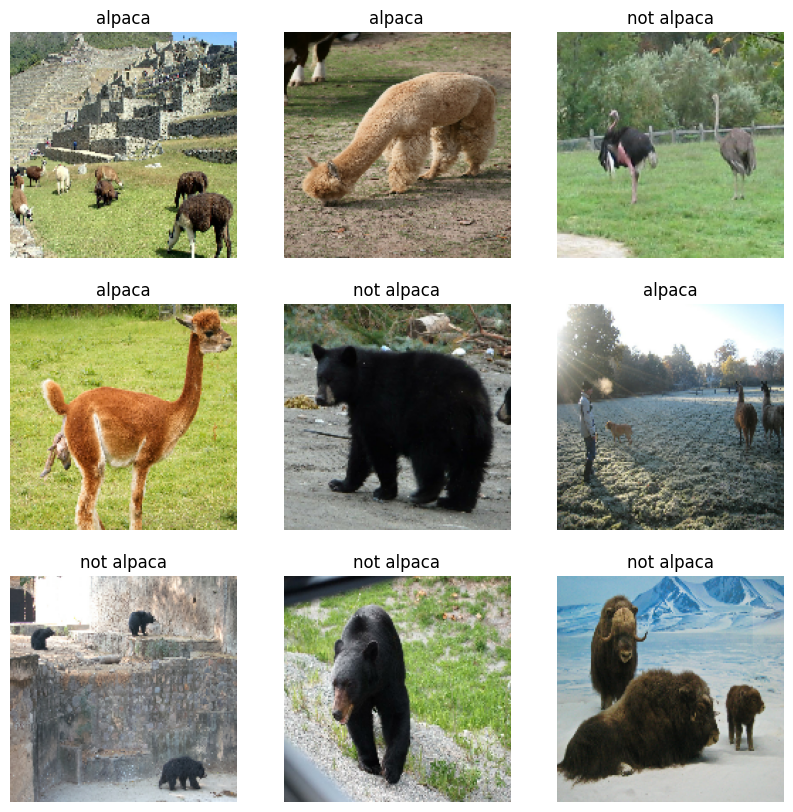

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## A (Relatively) Simple Model

If we try to learn these with a *very* simple model, we're gonna have a bad time. So, we'll use a *relatively* simple model, but one far more advanced than the first ones we'll be investigating in this class.

That's OK. All we really want to do here is investigate how we'd measure the success of this model, and we don't need to understand exactly what it's doing in order to do that.

So, what we'll do below is build a simple convolutional neural network, that will output a binary classification ("llama or not") for our problem.

In [6]:
inputs = keras.Input(shape=(160, 160, 3))
x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)

x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

We'll now compile the model you created. Again, no need to worry about the details yet.

In [7]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop")

Now we need to train the model. This may take a minute.

In [8]:
model.fit(train_dataset, epochs = 10);

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.8174
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 0.6906
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - loss: 0.6876
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 0.6874
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 0.6617
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 0.6417
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 0.6799
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 0.5996
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 0.6100
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 0.5644


## Assessing The Model's Performance

So, how well does this model do? First, let's create an array of the model's predictions on the training dataset. We can do this with the *model.predict* method.

In [9]:
y_pred = model.predict(inference_dataset)

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 730ms/step


This has now run the prediction model on the training data, and created an array of those predictions. However, we'll want to flatten it into a single dimension, so let's do that first, and then take a look at it (just the first ten elements):

In [10]:
y_pred = y_pred.flatten()

In [11]:
y_pred[:10]

array([0.48331723, 0.41243327, 0.50405836, 0.5004257 , 0.5156307 ,
       0.49085897, 0.9763689 , 0.48845032, 0.52786165, 0.49876627],
      dtype=float32)

Now, let's grab the actual labels from our dataset.

In [12]:
label_list = []
for _, labels in inference_dataset:
  label_list.append(labels.numpy())
y_true = np.concatenate(label_list)
#Note - This isn't a particularly Pythonic way to do it, but I think it's clearer.

We'll take a look at this array as well. Note that it starts with all the Alpacas, and then follows that with all the non-Alpacas.

In [13]:
y_true

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Let's now create an array of actual predictions ("Alpaca or not") from our probabilities:

In [14]:
y_pred_classes = np.round(y_pred).astype(int)

Now *y_pred_classes* are a bunch of $0$s and $1$s as well.

In [15]:
y_pred_classes

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Now it's your turn. Let's assess how good this model was. First, what was the accuracy score?

In [16]:
#YOUR CODE HERE
#percentage of cases where model is correct

accuracy = accuracy_score(y_true, y_pred_classes)
accuracy

#END CODE

0.6422018348623854

Next, what is the precision?

In [18]:
#YOUR CODE HERE
#how frequently the model is correct when it predicts a positive
precision_score(y_true, y_pred_classes)


#END CODE

0.6504424778761062

What is the recall?

In [19]:
#YOUR CODE HERE
#percentage of actual positives identified by model

recall_score(y_true, y_pred_classes)
#END CODE

0.7945945945945946

Create the confusion matrix.

In [20]:
#YOUR CODE HERE
#shows error and success types
cm = confusion_matrix(y_true, y_pred_classes)
cm

#END CODE
#true negatives #false negatives
#false negatives #true positives

array([[ 63,  79],
       [ 38, 147]])

Finally, draw the ROC curve for this model.

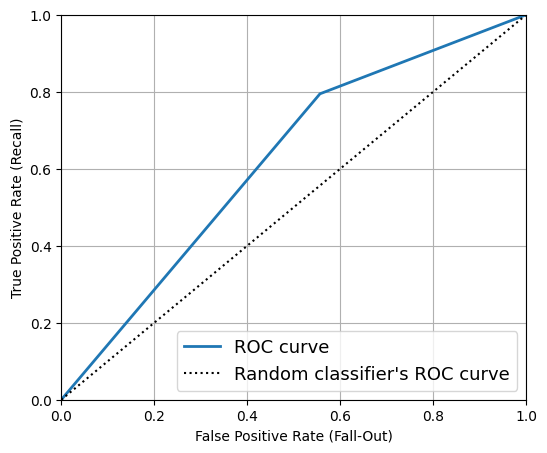

In [25]:
#YOUR CODE HERE
#plots false positives against true positives

fpr, tpr, thresholds = roc_curve(y_true, y_pred_classes)

plt.figure(figsize=(6, 5))  # Formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")


# plotting
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()
#END CODE

And, calculate it's AUC score.

In [26]:
#YOUR CODE HERE
#area under curve (1 for perfect classifier and .5 for random classifier)
roc_auc_score(y_true, y_pred_classes)

#END CODE

np.float64(0.6191282832127902)

The model we've built here is not very good. That's OK. We might have a later assignment where we look at ways we can improve it.

For this assignment, you should upload a link to your modified Colab notebook to Canvas.

<center>
    <div>
        <img src="https://drive.google.com/uc?export=view&id=1jjV9teAyrbNFDB1o8shMLpD6CrrllxWa" width = 300/>
    </div>
</center>

Alpaca!